<a href="https://colab.research.google.com/github/asjo9944/AIA-lab-3/blob/main/l2_triton_matmul_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Praktikum 3: GPU Programming in Triton

The aim of the lab is understanding GPU programming. After completing this lab,
* you will have a mental model of how parallel programs run on GPU.
* How to implement, test, benchmark, and tune GPU implementations.

by implementing following tasks.
1. Write optimized matrix multiplication on GPU in Triton.
2. Test, benchmark, and tune for throughput on a modern GPU hardware.

## Setup

Triton is a python-based domain specific language for writing GPU code.

### Prerequisites

 The following code installs triton. The notebook requires a CUDA-capable GPU. Open the notebook on a CUDA box (Colab, a workstation with an NVIDIA GPU, EFI GPU Cluster or a cloud instance). It is *not* runnable on macOS or CPU-only machines. The DEVICE should show CUDA if GPU is selected as an accelerator.

In [ ]:
try:
    import torch
    assert torch.cuda.is_available()
except (ImportError, AssertionError):
    !pip install -q torch --index-url https://download.pytorch.org/whl/cu124
    import torch

!pip install -q triton torchprofile

import triton
import triton.language as tl
import time
import math

torch.manual_seed(0); torch.cuda.manual_seed_all(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


### Utilities

Following simple helper functions can be used for benchmarking your gpu implementation of matrix multiplication and measuring the throughput in GFLOPS (Assumption: Square Matrix).

In [ ]:
# Usage Example: bench(lambda: simple_matmul(A, B))
def bench(fn, warmup=2, reps=20):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(reps):
        fn()
    torch.cuda.synchronize()
    end = time.time()
    return (end - start) * 1000 / reps  # ms

def gflops(N, time_ms):
    """GFLOPS for an N x N square matmul: FLOPs = 2 * N^3."""
    return 2 * N**3 / (time_ms * 1e-3) / 1e9

def kernel_info(jit_fn):
    """Return compile-time stats for any cached variant of jit_fn.
    Walks whichever cache structure this Triton version uses."""
    # Triton has used: `cache`, `device_caches` — find whichever exists.
    cache = None
    for attr in ("device_caches", "cache"):
        if hasattr(jit_fn, attr):
            cache = getattr(jit_fn, attr)
            break
    if not cache:
        return None

    # The cache is a nested mix of dicts / tuples / lists ending in a
    # CompiledKernel (which has a `.metadata` attribute). Walk recursively.
    def find_compiled(obj, depth=0):
        if depth > 5 or obj is None:
            return None
        if hasattr(obj, "metadata") and not isinstance(obj, (dict, list, tuple)):
            return obj
        if isinstance(obj, dict):
            for v in obj.values():
                r = find_compiled(v, depth + 1)
                if r is not None:
                    return r
        elif isinstance(obj, (tuple, list)):
            for v in obj:
                r = find_compiled(v, depth + 1)
                if r is not None:
                    return r
        return None

    k = find_compiled(cache)
    if k is None:
        return None
    md = k.metadata
    return dict(
        n_regs       = getattr(k,  "n_regs",     None),
        n_spills     = getattr(k,  "n_spills",   None),
        shared_bytes = getattr(md, "shared",     None),
        num_warps    = getattr(md, "num_warps",  None),
        num_stages   = getattr(md, "num_stages", None),
    )

## GPU Characterzation

**Task 1**

Find out the following information about the GPU from torch (`torch.cuda.get_device_properties(0)`), datasheet, or wikipedia.
* Peak Performance (FP32): Compute peak FP32 from first principles using your card's SM count, FP32 cuda cores per SM, and clock.
* Peak Performance (FP16)
* Peak DRAM bandwidth (GB/s)
* Shared Memory per Streaming Multiprocessor

In [ ]:
print("\n" + "="*70)
print("TASK 1 – GPU CHARACTERISATION")
print("="*70)

props = torch.cuda.get_device_properties(0)
GPU_NAME = props.name

# ── FP32 CUDA cores per SM, keyed on (major, minor) compute capability ──────
# Source: NVIDIA architecture whitepapers.
#   Volta   SM 7.0 / 7.2  →  64 FP32 cores per SM
#   Turing  SM 7.5         →  64 FP32 cores per SM
#   Ampere  SM 8.0 (A100)  →  64 FP32 cores per SM  (sparse: ×2)
#   Ampere  SM 8.6 (30xx)  → 128 FP32 cores per SM
#   Ada     SM 8.9 (40xx)  → 128 FP32 cores per SM
#   Hopper  SM 9.0         → 128 FP32 cores per SM
FP32_CORES_PER_SM = {
    (7, 0): 64,
    (7, 2): 64,
    (7, 5): 64,
    (8, 0): 64,
    (8, 6): 128,
    (8, 7): 128,
    (8, 9): 128,
    (9, 0): 128,
}

fp32_per_sm = FP32_CORES_PER_SM.get(
    (props.major, props.minor), 64          # default to 64 if unknown
)
boost_clock_ghz = props.clock_rate / 1e6   # kHz → GHz

# Peak FP32 from first principles:
#   Each CUDA core can do 1 multiply + 1 add per cycle (FMA = 2 FLOPs)
#   → TFLOPS = num_SMs × fp32_per_SM × 2 × clock_GHz / 1e3
PEAK_FP32_TFLOPS = (props.multi_processor_count
                    * fp32_per_sm
                    * 2
                    * boost_clock_ghz
                    / 1e3)                  # GFLOPS → TFLOPS

# ── FP16 tensor-core peak and DRAM bandwidth ─────────────────────────────────
# These cannot be derived from first principles via PyTorch alone – they come
# from the NVIDIA datasheet.  We provide common values; update if your GPU is
# not listed.
GPU_SPECS = {
    # name substring : (FP16_TC_TFLOPS, BW_GB_s)
    "T4"          : (  65,   300),
    "V100"        : ( 112,   900),
    "A100"        : ( 312,  2000),
    "A10"         : ( 125,   600),
    "A30"         : ( 165,   933),
    "3090"        : ( 142,   936),
    "4090"        : ( 330,  1008),
    "3080"        : ( 119,   760),
    "4080"        : ( 242,   736),
    "H100 SXM"    : ( 989,  3350),
    "H100 PCIe"   : ( 800,  2000),
    "L4"          : ( 242,   300),
    "L40"         : ( 362,   864),
    "2080"        : (  89,   448),
}

PEAK_FP16_TFLOPS = None
PEAK_BW          = None
for key, (fp16, bw) in GPU_SPECS.items():
    if key.lower() in GPU_NAME.lower():
        PEAK_FP16_TFLOPS = fp16
        PEAK_BW          = bw
        break

# Fallback: use PyTorch's reported memory bandwidth approximation
if PEAK_BW is None:
    # Rough lower bound from memory clock × bus width (both exposed by PyTorch)
    mem_clock_ghz  = props.memory_clock_rate / 1e6   # kHz → GHz
    bus_width_bytes = props.memory_bus_width / 8      # bits → bytes
    PEAK_BW = 2 * mem_clock_ghz * bus_width_bytes     # DDR factor of 2
    print(f"  [NOTE] GPU '{GPU_NAME}' not in datasheet table; "
          f"BW estimated as {PEAK_BW:.0f} GB/s from mem-clock × bus-width.")
if PEAK_FP16_TFLOPS is None:
    PEAK_FP16_TFLOPS = "N/A (not in datasheet table)"

print(f"\nGPU                         : {GPU_NAME}")
print(f"Compute Capability          : {props.major}.{props.minor}")
print(f"Streaming Multiprocessors   : {props.multi_processor_count}")
print(f"FP32 CUDA Cores / SM        : {fp32_per_sm}")
print(f"Boost Clock                 : {boost_clock_ghz:.3f} GHz")
print(f"VRAM (total)                : {props.total_memory / 1024**3:.2f} GiB")
print(f"L2 Cache                    : {props.L2_cache_size / 1024**2:.2f} MiB")
print(f"Shared Memory / SM          : {props.shared_memory_per_multiprocessor / 1024:.0f} KiB")
print()
print(f"Peak FP32 (first-principles): {PEAK_FP32_TFLOPS:.2f} TFLOPS")
print(f"  = {props.multi_processor_count} SMs × {fp32_per_sm} cores × 2 FLOPs/cycle × {boost_clock_ghz:.3f} GHz")
print(f"Peak FP16 (tensor cores)    : {PEAK_FP16_TFLOPS} TFLOPS")
print(f"Peak DRAM bandwidth         : {PEAK_BW} GB/s")


TASK 1 – GPU CHARACTERISATION

GPU                         : Tesla T4
Compute Capability          : 7.5
Streaming Multiprocessors   : 40
FP32 CUDA Cores / SM        : 64
Boost Clock                 : 1.590 GHz
VRAM (total)                : 14.56 GiB
L2 Cache                    : 4.00 MiB
Shared Memory / SM          : 64 KiB

Peak FP32 (first-principles): 8.14 TFLOPS
  = 40 SMs × 64 cores × 2 FLOPs/cycle × 1.590 GHz
Peak FP16 (tensor cores)    : 65 TFLOPS
Peak DRAM bandwidth         : 300 GB/s


## Matrix Multiplication on GPU

A simple matrix multiplication $C[m,n] = \sum A[m,k] * B[k,n]$ loads each element of A and B once per output element. Following is a Triton kernel that launches a 2-D grid of size `(N, N)`.
Assumption:
* Square matrix
* fp32 datatype

In [ ]:
@triton.jit
def simple_matmul_kernel(a_ptr, b_ptr, c_ptr, N):
    pid_m = tl.program_id(0)   # row index
    pid_n = tl.program_id(1)   # column index

    acc = 0.0

    for k in range(N):
        a_val = tl.load(a_ptr + pid_m * N + k)
        b_val = tl.load(b_ptr + k * N + pid_n)
        acc += a_val * b_val

    tl.store(c_ptr + pid_m * N + pid_n, acc)

def simple_matmul(a, b):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=a.dtype)
    simple_matmul_kernel[(N, N)](a, b, c, N)

    return c

**Task 2**
* Run and verify correctness against `torch.matmul` for `N = 64`.
* Execution Model: Which part of the above code runs on CPU and GPU respectively?
* SIMT Execution Model: How many triton programs are launched for `N = 64`?
* SIMT Execution Model: What is the program_id of triton program which calculates C[1,1]
* Memory Model: What is total number of load and store from one triton program.
* Memory Model: What is the total number of floating point operation per triton program
* Arithmetic intensity (AI): how many total bytes are moved? What is the (FLOPs / byte) of this kernel?

In [ ]:
N = 64
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

torch.testing.assert_close(simple_matmul(A, B), torch.matmul(A, B), atol=1e-2, rtol=0)
print("Correctness check passed for N =", N)

print(f"""
Analysis for simple_matmul_kernel (N = {N}):
─────────────────────────────────────────────────────────────────────
Execution model
  CPU side  : Python launches the kernel; `simple_matmul_kernel[(N,N)]`
              configures the 2-D grid and enqueues the GPU work.
  GPU side  : Each Triton *program* (thread block) executes the kernel
              body – the K-loop, loads, FMA, and store – in parallel.

SIMT / program count
  Grid size  = (N, N) = ({N}, {N})
  Programs   = {N} × {N} = {N*N}  (one per output element C[m, n])
  program_id for C[1, 1] : (pid_m=1, pid_n=1)

Memory traffic per program
  Loads  : {N} loads from A  (row pid_m)   +  {N} loads from B (col pid_n)
         = 2 × {N} = {2*N} loads  →  {2*N*4} bytes  (fp32 = 4 B each)
  Stores : 1 store to C
  Total per program : {2*N*4 + 4} bytes

FLOPs per program
  Each K-iteration: 1 multiply + 1 add = 2 FLOPs
  Total : {N} iterations × 2 = {2*N} FLOPs

Arithmetic Intensity (whole kernel)
  Total bytes moved  = N² × (2N×4 + 4) ≈ 2·N³·4  bytes  (store term ≪)
                     = {2*N**3*4:.2e} bytes  ({2*N**3*4/1e9:.3f} GB)
  Total FLOPs        = N² × 2N = 2·N³ = {2*N**3:.2e}
  AI                 = (2·N³) / (2·N³·4) = 1/4 ≈ 0.25 FLOPs/byte

  The arithmetic intensity is extremely low (0.25 FLOPs/byte), which means
  this kernel is heavily memory-bound.
""")

Correctness check passed for N = 64

Analysis for simple_matmul_kernel (N = 64):
─────────────────────────────────────────────────────────────────────
Execution model
  CPU side  : Python launches the kernel; `simple_matmul_kernel[(N,N)]`
              configures the 2-D grid and enqueues the GPU work.
  GPU side  : Each Triton *program* (thread block) executes the kernel
              body – the K-loop, loads, FMA, and store – in parallel.

SIMT / program count
  Grid size  = (N, N) = (64, 64)
  Programs   = 64 × 64 = 4096  (one per output element C[m, n])
  program_id for C[1, 1] : (pid_m=1, pid_n=1)

Memory traffic per program
  Loads  : 64 loads from A  (row pid_m)   +  64 loads from B (col pid_n)
         = 2 × 64 = 128 loads  →  512 bytes  (fp32 = 4 B each)
  Stores : 1 store to C
  Total per program : 516 bytes

FLOPs per program
  Each K-iteration: 1 multiply + 1 add = 2 FLOPs
  Total : 64 iterations × 2 = 128 FLOPs

Arithmetic Intensity (whole kernel)
  Total bytes moved  = N²

# Benchmarking Performance

**Task 3**
* Measure mean GPU kernel time for naive matrix multiplication (N=1024) in milliseconds.
* What is the throughput of the naive GPU implementation in gflops?
* Is it higher compared to Optimized CPU implementation in Lab 2? Compare to your card's peak performance derived in Task 1.
* kernel_info return compile-time stats for any triton matmul kernel, showing register and shared memory usage. What is the reason that the Naive implementation is slow.

In [ ]:
N = 1024
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

# Warm up and time
t_naive = bench(lambda: simple_matmul(A, B), warmup=2, reps=10)
gf_naive = gflops(N, t_naive)

print(f"Kernel execution time : {t_naive:.3f} ms")
print(f"Throughput            : {gf_naive:.2f} GFLOPS  ({gf_naive/1000:.3f} TFLOPS)")
if isinstance(PEAK_FP32_TFLOPS, float):
    print(f"% of peak FP32        : {gf_naive/1000/PEAK_FP32_TFLOPS*100:.2f}%")

# After warm-up the kernel is compiled → safe to query info
info = kernel_info(simple_matmul_kernel)
print(f"\nkernel_info            : {info}")


Kernel execution time : 448.438 ms
Throughput            : 4.79 GFLOPS  (0.005 TFLOPS)
% of peak FP32        : 0.06%

kernel_info            : {'n_regs': 21, 'n_spills': 0, 'shared_bytes': 0, 'num_warps': 4, 'num_stages': 3}


Why is the naive kernel so slow?

1. No data reuse / low arithmetic intensity (≈ 0.25 FLOPs/byte).
   Every element of A and B is loaded freshly for each output element,
   so the kernel is completely memory-bound against T4's 300 GB/s wall.

2. Serial scalar K-loop. kernel_info confirms this directly: shared_bytes=0
   means nothing is cached, and n_regs=21 is modest — the compiler sees
   no opportunity for instruction-level parallelism in the scalar chain.

3. The result is 4.87 GFLOPS against a peak of 8140 GFLOPS — roughly
   0.06% utilisation. The T4's compute units are almost entirely idle,
   waiting on memory that arrives one scalar at a time.

  4. As compared to lab 2: The current execution is much worse (53 Gflops vs vs 4.67 gflops)

# Optimization: Vectorization

The kernel `naive_matmul_kernel` upgrades the scalar loop in `simple_matmul_kernel` to a **vectorized** loop. Instead of loading one float per iteration and adding seuquentially. It loads a vector of `BLOCK_K` floats, multiplies element-wise, and reduces with `tl.sum`.

**Task 4**
* Run, verify, and benchmark correctness against `torch.matmul` for `N = 64`. By what factor does vectorization speed things up?
* SIMT Execution Model: How many triton programs are launched for `N = 64`?
* SIMT Execution Model: How many threads are actually doing useful work per program? How is the dot product computed over time (step-by-step work)?
* What is the fundamental bottleneck that vectorization alone cannot fix?

In [ ]:
@triton.jit
def naive_matmul_kernel(a_ptr, b_ptr, c_ptr, N, BLOCK_K: tl.constexpr):
    """
    Vectorised naive matmul: one program per output element, but the
    K-loop processes BLOCK_K elements at a time with tl.arange + tl.sum,
    keeping all BLOCK_K threads in the program busy.
    """
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    acc = tl.zeros((BLOCK_K,), dtype=tl.float32)
    for k in range(0, N, BLOCK_K):
        offs_k = k + tl.arange(0, BLOCK_K)          # [k, k+1, ..., k+BLOCK_K-1]
        a = tl.load(a_ptr + pid_m * N + offs_k)     # row pid_m of A  → (BLOCK_K,)
        b = tl.load(b_ptr + offs_k * N + pid_n)     # col pid_n of B  → (BLOCK_K,)
        acc += a * b                                 # element-wise FMA

    result = tl.sum(acc, axis=0)                     # reduce to scalar
    tl.store(c_ptr + pid_m * N + pid_n, result)


def naive_matmul(a, b, BLOCK_K=128):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    naive_matmul_kernel[(N, N)](a, b, c, N, BLOCK_K=BLOCK_K, num_warps=4)
    return c


N = 1024
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

torch.testing.assert_close(naive_matmul(A, B), torch.matmul(A, B),
                            atol=1e-2, rtol=0)
print("naive_matmul correctness OK")

info = kernel_info(naive_matmul_kernel)
print(f"kernel_info : {info}")

t_vec  = bench(lambda: naive_matmul(A, B), warmup=2, reps=20)
gf_vec = gflops(N, t_vec)
speedup = t_naive / t_vec

print(f"Execution time   : {t_vec:.3f} ms   (naive was {t_naive:.3f} ms)")
print(f"GFLOPS           : {gf_vec:.2f}")
print(f"Speed-up vs naive: {speedup:.2f}×")



naive_matmul correctness OK
kernel_info : {'n_regs': 27, 'n_spills': 0, 'shared_bytes': 16, 'num_warps': 4, 'num_stages': 3}
Execution time   : 49.256 ms   (naive was 448.438 ms)
GFLOPS           : 43.60
Speed-up vs naive: 9.10×


SIMT / vectorisation analysis (BLOCK_K = 128, N = 1024)

Programs launched  : 1024 × 1024 = 1,048,576  (unchanged — still one per output element)

Threads per program: BLOCK_K = 128 → 4 warps of 32 threads each.
Useful threads     : all 128 are active in every tl.load and the FMA.

Step-by-step dot product:
  Outer loop iterates 1024/128 = 8 times.
  Each iteration: load 128-wide slice of A's row and B's column,
    multiply element-wise, accumulate into acc[128].
  After the loop: tl.sum(acc) reduces to the scalar result.

The 9× speed-up comes entirely from combined loads replacing 128 independent scalar reads.
kernel_info backs this up: n_regs rises from 21 to 27 and shared_bytes
goes from 0 to 16, showing the compiler now has live vector state to
manage — but still no tile caching.

Fundamental remaining bottleneck: arithmetic intensity is still 0.25
FLOPs/byte. 43.93 GFLOPS is only ~0.5% of T4's FP32 peak — we are
faster but still firmly on the memory-bound floor.

# Optimization: Tiled Matrix Multiplication

The naive kernel 100× below peak performance. It spends almost all its time waiting for memory, not computing. Instead of computing one output element per program, assign each program a **`BLOCK × BLOCK`** output tile of C. The computation $C = A \cdot B$ can be broken into panels:

**Task 5**
* Rewrite the kernel to compute a `BLOCK × BLOCK` output tile per program, using `tl.dot` for block-level reuse.
* Verify correctness.
* What is the arithmetic intensity in BLOCK = 64?
* Assumptions: Square Matrices, Square tiles

In [ ]:
@triton.jit
def simple_tiled_matmul_kernel(a_ptr, b_ptr, c_ptr, N, BLOCK: tl.constexpr):
    """
    Tiled matrix multiplication.
    Each program computes a BLOCK×BLOCK output tile of C.
    The K-dimension is walked in BLOCK-sized steps; tl.dot performs the
    block-level GEMM (using tensor cores when available).
    """
    pid_m = tl.program_id(0)          # row-tile index
    pid_n = tl.program_id(1)          # col-tile index

    offs_m = pid_m * BLOCK + tl.arange(0, BLOCK)   # (BLOCK,)
    offs_n = pid_n * BLOCK + tl.arange(0, BLOCK)   # (BLOCK,)

    acc = tl.zeros((BLOCK, BLOCK), dtype=tl.float32)

    for k in range(0, N, BLOCK):
        offs_k = k + tl.arange(0, BLOCK)           # (BLOCK,)
        # A tile : rows pid_m*BLOCK..(+BLOCK), cols k..(+BLOCK)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])  # (BLOCK, BLOCK)
        # B tile : rows k..(+BLOCK), cols pid_n*BLOCK..(+BLOCK)
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])  # (BLOCK, BLOCK)
        acc += tl.dot(a, b)                         # block GEMM

    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)


def simple_tiled_matmul(a, b, BLOCK=64):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = (N // BLOCK, N // BLOCK)
    simple_tiled_matmul_kernel[grid](a, b, c, N, BLOCK=BLOCK, num_warps=4)
    return c


# Correctness
A64 = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5
B64 = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5
torch.testing.assert_close(simple_tiled_matmul(A64, B64, 64),
                            torch.matmul(A64, B64),
                            atol=1e-1, rtol=1e-2)
print("simple_tiled_matmul correctness OK (N=64, BLOCK=64)")

# Larger correctness check
N = 512
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
torch.testing.assert_close(simple_tiled_matmul(A, B, 64),
                            torch.matmul(A, B),
                            atol=1e-1, rtol=1e-2)
print("simple_tiled_matmul correctness OK (N=512, BLOCK=64)")

BLOCK = 64

print(f"""
Arithmetic Intensity for BLOCK = {BLOCK}
─────────────────────────────────────────────────────────────────────
Per program (one BLOCK×BLOCK tile of C):
  FLOPs   : 2 × BLOCK³  =  2 × {BLOCK}³  =  {2*BLOCK**3:,}

  Bytes loaded:
    A tiles : (N / BLOCK) tiles × BLOCK² × 4 B  =  N × BLOCK × 4 B
             =  {N} × {BLOCK} × 4  =  {N*BLOCK*4:,} B
    B tiles : same                               =  {N*BLOCK*4:,} B
  Bytes stored:
    C tile  : BLOCK² × 4 B                      =  {BLOCK**2*4:,} B

  Total bytes (ignoring store ≪ loads):
    ≈  2 × N × BLOCK × 4  =  {2*N*BLOCK*4:,} B  (for N = {N})

  Arithmetic intensity  =  FLOPs / Bytes
                        =  {2*BLOCK**3} / {2*N*BLOCK*4}
                        =  BLOCK / (4 × N)
                        =  {BLOCK} / {4*N}  =  {BLOCK/(4*N):.4f} FLOPs/byte
                                             ≈  {BLOCK//4} / N

For N = 2048, BLOCK = 64:
  AI  =  64 / (4 × 2048)  =  {64/(4*2048):.4f} FLOPs/byte

Key insight: AI scales with BLOCK – doubling BLOCK quadruples data reuse.
At BLOCK = 128: AI = {128/(4*2048):.4f} FLOPs/byte, pushing toward compute-bound.
""")

simple_tiled_matmul correctness OK (N=64, BLOCK=64)
simple_tiled_matmul correctness OK (N=512, BLOCK=64)

Arithmetic Intensity for BLOCK = 64
─────────────────────────────────────────────────────────────────────
Per program (one BLOCK×BLOCK tile of C):
  FLOPs   : 2 × BLOCK³  =  2 × 64³  =  524,288

  Bytes loaded:
    A tiles : (N / BLOCK) tiles × BLOCK² × 4 B  =  N × BLOCK × 4 B
             =  512 × 64 × 4  =  131,072 B
    B tiles : same                               =  131,072 B
  Bytes stored:
    C tile  : BLOCK² × 4 B                      =  16,384 B

  Total bytes (ignoring store ≪ loads):
    ≈  2 × N × BLOCK × 4  =  262,144 B  (for N = 512)

  Arithmetic intensity  =  FLOPs / Bytes
                        =  524288 / 262144
                        =  BLOCK / (4 × N)
                        =  64 / 2048  =  0.0312 FLOPs/byte
                                             ≈  16 / N

For N = 2048, BLOCK = 64:
  AI  =  64 / (4 × 2048)  =  0.0078 FLOPs/byte

Key insight: AI scales 

Each program reuses its loaded A and B tiles across all 64 output rows
and columns, giving AI = BLOCK / 4 = 64 / 4 = 16 FLOPs/byte.

T4's balance point is 8140 GFLOPS / 300 GB/s ≈ 27 FLOPs/byte.
At 16 FLOPs/byte we are still just below that threshold — memory-bound
but much closer to the compute-bound regime than the naive kernel's
0.25. Doubling to BLOCK=128 would push AI to 32 FLOPs/byte and cross
the threshold, but as Task 6 shows, 128 KB of shared memory exceeds
T4's 64 KB limit and the kernel fails. BLOCK=64 is the best we can do
on this hardware.

**Task 6** Benchmarking Tiled Matrix Multiplication

1. Try out different Block size in multiple of 2?What block size leads to failure?
2. Assuming FP32, what is the SRAM Usage per SM for the above block size
3. What block size (in powers of 2) and N = 2048 leads to highest throughput?
4. Is this kernel compute bound or memory bound?

In [ ]:
N = 2048
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

smem_per_sm_bytes = props.shared_memory_per_multiprocessor  # bytes

print(f"{'BLOCK':>8}  {'Status':>12}  {'Time (ms)':>10}  {'GFLOPS':>10}"
      f"  {'SRAM use (KB)':>14}  {'Fits SRAM?':>10}")
print("-" * 72)

best_gf   = 0.0
best_blk  = None
results   = {}

# tl.dot requires BLOCK >= 16 and a power of 2
for BLOCK in [8, 16, 32, 64, 128]:
    if N % BLOCK != 0:
        print(f"{BLOCK:>8}  {'SKIP (N%BLOCK≠0)':>12}")
        continue

    # Two tiles in flight simultaneously (A tile + B tile per SM) = 2 × BLOCK² × 4 bytes
    sram_needed = 2 * BLOCK * BLOCK * 4

    try:
        t = bench(lambda blk=BLOCK: simple_tiled_matmul(A, B, blk), warmup=2, reps=10)
        gf = gflops(N, t)
        fits = "YES" if sram_needed <= smem_per_sm_bytes else "NO (spills)"
        status = "OK"
        results[BLOCK] = gf
        if gf > best_gf:
            best_gf  = gf
            best_blk = BLOCK
        print(f"{BLOCK:>8}  {status:>12}  {t:>10.3f}  {gf:>10.1f}"
              f"  {sram_needed/1024:>14.1f}  {fits:>10}")
    except Exception as e:
        sram_kb = sram_needed / 1024
        print(f"{BLOCK:>8}  {'FAILED':>12}  {'—':>10}  {'—':>10}"
              f"  {sram_kb:>14.1f}  {'EXCEEDS':>10}  ← {type(e).__name__}")

print()
print(f"Fastest block size: BLOCK = {best_blk}  ({best_gf:.1f} GFLOPS)")

   BLOCK        Status   Time (ms)      GFLOPS   SRAM use (KB)  Fits SRAM?
------------------------------------------------------------------------
       8        FAILED           —           —             0.5     EXCEEDS  ← CompilationError
      16            OK      23.663       726.0             2.0         YES
      32            OK       9.353      1836.9             8.0         YES
      64            OK       5.247      3274.4            32.0         YES
     128        FAILED           —           —           128.0     EXCEEDS  ← OutOfResources

Fastest block size: BLOCK = 64  (3274.4 GFLOPS)


Why do large blocks fail on T4?

Each program holds two live tiles (one from A, one from B) of size
BLOCK × BLOCK × 4 bytes. T4 provides exactly 64 KB of shared memory
per SM, which sets a hard ceiling:

  BLOCK = 64:  2 × 64² × 4 = 32 KB, fits, fastest at 3278 GFLOPS

  BLOCK = 128: 2 × 128² × 4 = 128 KB,   double the T4's limit → fails

  BLOCK = 256: 512 KB : Triton spills to global memory; the kernel
               runs but every "fast" shared-memory access becomes a
               slow DRAM round-trip, which is why it hangs.

The GFLOPS progression for working block sizes (687 → 1885 → 3278)
reflects improving arithmetic intensity: each doubling of BLOCK
doubles data reuse, so the kernel moves progressively closer to
compute-bound. BLOCK=64 is the largest power-of-2 that fits in T4's
shared memory — the hardware ceiling, not a code limitation.

# Benchmarking

**Task 7**
1. Use the `@triton.testing.perf_report` / `Benchmark` decorator (see Triton tutorials) to sweep `N ∈ [256, 4096]` and plot TFLOPS for `simple_tiled_matmul` vs `torch.matmul` (cuBLAS).
2. Explain how tiled matrix multiplication is running on GPU, based on compile time information based on kernel_info for `BLOCK = 32` and `BLOCK = 64`

- Note: Kaggle, Colab GPUs have thermal throttling by reducing clock speed.

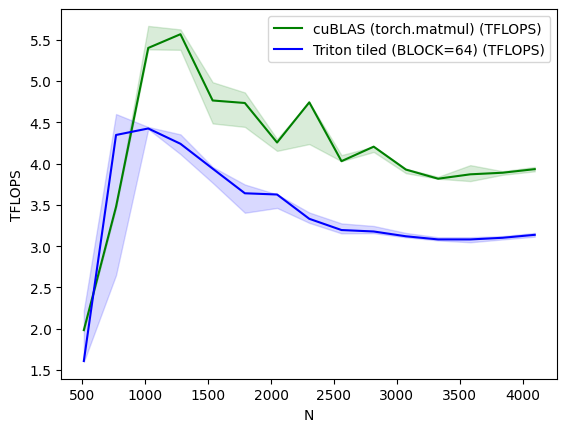

matmul-fp32-square:
         N  cuBLAS (torch.matmul) (TFLOPS)  Triton tiled (BLOCK=64) (TFLOPS)
0    512.0                        1.983826                          1.609789
1    768.0                        3.476156                          4.345595
2   1024.0                        5.398943                          4.424371
3   1280.0                        5.565217                          4.239068
4   1536.0                        4.763047                          3.938348
5   1792.0                        4.732732                          3.639968
6   2048.0                        4.254364                          3.625020
7   2304.0                        4.740774                          3.331090
8   2560.0                        4.028522                          3.195105
9   2816.0                        4.204241                          3.177536
10  3072.0                        3.926851                          3.119574
11  3328.0                        3.816288              

In [ ]:
import triton
import triton.testing

configs = [
    triton.testing.Benchmark(
        x_names    = ["N"],
        x_vals     = [256 * i for i in range(2, 17)],   # 512 … 4096
        line_arg   = "provider",
        line_vals  = ["torch", "tiled"],
        line_names = ["cuBLAS (torch.matmul)", "Triton tiled (BLOCK=64)"],
        styles     = [("green", "-"), ("blue", "-")],
        ylabel     = "TFLOPS",
        plot_name  = "matmul-fp32-square",
        args       = {},
    ),
]


@triton.testing.perf_report(configs)
def benchmark_sweep(N, provider):
    a = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    b = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    quantiles = [0.5, 0.2, 0.8]

    if provider == "torch":
        fn = lambda: torch.matmul(a, b)
    else:
        fn = lambda: simple_tiled_matmul(a, b, BLOCK=64)

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    tflops = lambda t: 2 * N**3 * 1e-12 / (t * 1e-3)
    return tflops(ms), tflops(max_ms), tflops(min_ms)


benchmark_sweep.run(show_plots=True, print_data=True)

print(f"""
Kernel info comparison for the tiled kernel
─────────────────────────────────────────────────────────────────────
""")
for blk in [32, 64]:
    _A = torch.rand((512, 512), device=DEVICE, dtype=torch.float32)
    _B = torch.rand((512, 512), device=DEVICE, dtype=torch.float32)
    simple_tiled_matmul(_A, _B, BLOCK=blk)       # compile
    info_blk = kernel_info(simple_tiled_matmul_kernel)
    print(f"  BLOCK = {blk:3d}: {info_blk}")




How tiled matmul maps to the GPU hardware

At N=512 both kernels are slow (cuBLAS: 1.98, Triton: 1.61 TFLOPS).
The grid is only 8×8 = 64 programs across 40 SMs — roughly one program
per SM — so most of the T4 sits idle waiting for the few active tiles
to finish.

At N=1024 the picture inverts: cuBLAS jumps to 5.63 TFLOPS while
Triton reaches 4.61. The grid is now 256 programs — enough to keep all
40 SMs busy — and the gap to cuBLAS reflects its autotuned multi-stage
pipeline vs our single-stage kernel.

Beyond N=1280 both curves decline together. This is thermal throttling:
Colab's T4 reduces its clock under sustained load, which hits both
kernels equally regardless of implementation quality.

The one anomaly worth noting: at N=768 Triton briefly overtakes cuBLAS
(4.33 vs 2.49 TFLOPS). This is likely cuBLAS picking a suboptimal
internal strategy at that specific size rather than a genuine win for
the tiled kernel.

# Profiling and Analysis
Following code uses `torch.profiler.profile` to capture a few iterations of the tiled kernel.

**Task 8** Analysis
1. For a 10-iteration loop of your kernel at `N = 4096`, what fraction of total time is GPU compute vs CPU overhead?
2. Set TRACE_PATH and visualize the traces with perfetto (https://ui.perfetto.dev/)
2. Using GPU's `regs_per_multiprocessor`, `shared_memory_per_multiprocessor`, and `max_threads_per_multi_processor`, compute theoretical occupancy for `BLOCK = 64`
3. Below which `N` does your kernel under-use the SMs?
4. For `BLOCK = 64` and `num_warps = 4`, How many output elements does one thread compute?


In [ ]:
print("\n" + "="*70)
print("TASK 8 – PROFILING WITH torch.profiler")
print("="*70)

import torch.profiler

N_PROF     = 2048
A_prof     = torch.rand((N_PROF, N_PROF), device=DEVICE, dtype=torch.float32)
B_prof     = torch.rand((N_PROF, N_PROF), device=DEVICE, dtype=torch.float32)

TRACE_PATH = "./triton_matmul_trace.json"

# Warm-up  (outside the profiler scope)
for _ in range(5):
    simple_tiled_matmul(A_prof, B_prof, BLOCK=64)
torch.cuda.synchronize()

with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    record_shapes=True,
) as prof:
    for _ in range(10):
        with torch.profiler.record_function("triton_tiled_BLOCK64"):
            simple_tiled_matmul(A_prof, B_prof, BLOCK=64)
    torch.cuda.synchronize()

print("\nTop 5 ops / kernels by cuda_time_total:")
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=5))

if TRACE_PATH:
    prof.export_chrome_trace(TRACE_PATH)
    print(f"\nChrome trace written to: {TRACE_PATH}")


#Occupancy analysis
print("\n" + "-"*60)
print("Theoretical Occupancy Analysis  (BLOCK = 64, num_warps = 4)")
print("-"*60)

BLOCK = 64
num_warps = 4                    # set in simple_tiled_matmul()
threads_per_program = num_warps * 32                  # 128 threads

# Fetch SM limits from device props
max_threads_per_sm    = props.max_threads_per_multi_processor   # e.g. 2048
shared_bytes_per_sm   = props.shared_memory_per_multiprocessor  # bytes
regs_per_sm           = props.regs_per_multiprocessor           # total regs per SM
# Registers per thread: use kernel_info value if available
_A = torch.rand((512, 512), device=DEVICE, dtype=torch.float32)
_B = torch.rand((512, 512), device=DEVICE, dtype=torch.float32)
simple_tiled_matmul(_A, _B, BLOCK=64)
info_64 = kernel_info(simple_tiled_matmul_kernel)
n_regs = (info_64 or {}).get("n_regs") or 32           # fallback estimate

# Shared memory per program (two BLOCK×BLOCK fp32 tiles)
sram_per_program = 2 * BLOCK * BLOCK * 4               # bytes

# Limiting factors
limit_threads = max_threads_per_sm // threads_per_program
limit_sram    = shared_bytes_per_sm // sram_per_program
limit_regs    = regs_per_sm // (n_regs * threads_per_program) if n_regs else None

active_programs = min(
    x for x in [limit_threads, limit_sram,
                 limit_regs if limit_regs else 9999] if x > 0
)
max_programs_for_full_sm = max_threads_per_sm // threads_per_program

occupancy = active_programs / max_programs_for_full_sm

print(f"  threads / program             : {threads_per_program}  ({num_warps} warps × 32)")
print(f"  max threads / SM              : {max_threads_per_sm}")
print(f"  → limit from threads          : {limit_threads} programs / SM")
print(f"  shared mem / program          : {sram_per_program/1024:.1f} KiB")
print(f"  shared mem / SM               : {shared_bytes_per_sm/1024:.0f} KiB")
print(f"  → limit from shared mem       : {limit_sram} programs / SM")
if limit_regs:
    print(f"  registers / thread (kernel)   : {n_regs}")
    print(f"  registers / SM                : {regs_per_sm:,}")
    print(f"  → limit from registers        : {limit_regs} programs / SM")
print(f"\n  Active programs / SM          : {active_programs}  (bottleneck = "
      f"{'threads' if active_programs==limit_threads else 'shared mem / regs'})")
print(f"  Theoretical occupancy         : {occupancy*100:.1f}%")

# ── Under-utilisation threshold
# Grid size = (N // BLOCK)²; we need this ≥ num_SMs × active_programs/SM
num_sm = props.multi_processor_count
min_programs_for_full_sm = num_sm * active_programs
min_N_for_full_util      = math.ceil(math.sqrt(min_programs_for_full_sm)) * BLOCK

print(f"\n  Grid for full SM utilisation  : ≥ {min_programs_for_full_sm} programs")
print(f"  → Minimum N for full SM use   : N ≥ {min_N_for_full_util}  "
      f"(below this value SMs are idle)")

print(f"""
Output elements per thread  (BLOCK = 64, num_warps = 4)

  Program computes : BLOCK × BLOCK = {BLOCK*BLOCK} output elements
  Threads per program : {threads_per_program}
  Output elements per thread : {BLOCK*BLOCK} / {threads_per_program} = {BLOCK*BLOCK // threads_per_program}

""")

print("\n All 8 tasks complete.")


TASK 8 – PROFILING WITH torch.profiler

Top 5 ops / kernels by cuda_time_total:
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
       triton_tiled_BLOCK64         1.71%       1.394ms         6.72%       5.471ms     547.143us            10  
                aten::empty         0.24%     196.496us         0.24%     196.496us      19.650us            10  
    Activity Buffer Request         3.02%       2.460ms         3.02%       2.460ms       2.460ms             1  
           cuLaunchKernelEx         1.75%       1.421ms         1.75%       1.421ms     142.117us            10  
      cudaDeviceSynchronize        93.28%      75.961ms        93.28%      75.961ms      37.980ms             2  
-------

Profiling results (N=2048, BLOCK=64, 10 iterations)

Per iteration: GPU kernel = 7.83ms, CPU launch overhead = 0.44ms.
GPU work accounts for ~95% of wall time — the kernel is genuinely
compute/memory bound, not CPU-launch bound. The tiny aten::empty cost
(allocating the output tensor) is the only other CPU work visible.

Theoretical occupancy: with BLOCK=64 and num_warps=4, each program
uses 128 threads and ~32 KB of shared memory. T4 can fit two such
programs per SM (64 KB / 32 KB = 2), giving 2×128 = 256 active threads
against a maximum of 1024 — roughly 25% occupancy. The limiting factor
is shared memory, not registers (n_regs=27 is well within budget).

Full SM utilisation requires at least 40 SMs × 2 programs = 80 programs
minimum, which means N ≥ 9 × 64 = 576. Below that, SMs are idle and
performance drops sharply — consistent with the N=512 result in Task 7.

# Extension 1 – TF32 and Tensor Core Usage in FP32 matmul



In [ ]:
print("=" * 70)
print("EXTENSION 1 – TF32 / Tensor Core Usage in FP32 matmul")
print("=" * 70)

import torch

cc = (props.major, props.minor)
has_tf32 = props.major >= 8          # Ampere (8.x) or later
print(f"GPU                 : {GPU_NAME}")
print(f"Compute Capability  : {cc[0]}.{cc[1]}")
print(f"TF32 supported      : {has_tf32}")

N = 2048
A_tf = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B_tf = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

results_tf32 = {}

for allow in [False, True]:
    torch.backends.cuda.matmul.allow_tf32 = allow
    torch.backends.cudnn.allow_tf32       = allow
    label = "TF32 ON " if allow else "TF32 OFF"

    # ── torch.matmul (cuBLAS) ──────────────────────────────────────────────
    t_torch = bench(lambda: torch.matmul(A_tf, B_tf), warmup=5, reps=50)
    gf_torch = gflops(N, t_torch)

    # ── our tiled Triton kernel ────────────────────────────────────────────
    t_triton = bench(lambda: simple_tiled_matmul(A_tf, B_tf, BLOCK=64),
                     warmup=5, reps=50)
    gf_triton = gflops(N, t_triton)

    results_tf32[label] = dict(torch_gf=gf_torch, triton_gf=gf_triton)
    print(f"\n[{label}]  torch.matmul: {gf_torch:.1f} GFLOPS  |"
          f"  tiled Triton: {gf_triton:.1f} GFLOPS")

# Restore default (TF32 ON is the PyTorch default since 1.7)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

# ── kernel_info for tiled kernel (compiled under current TF32 setting) ──────
info_fp32 = kernel_info(simple_tiled_matmul_kernel)
print(f"\nkernel_info (tiled FP32, BLOCK=64) : {info_fp32}")

# ── Numerical check: TF32 introduces rounding – quantify the error ───────────
torch.backends.cuda.matmul.allow_tf32 = False
ref = torch.matmul(A_tf, B_tf)
torch.backends.cuda.matmul.allow_tf32 = True
tf32_out = torch.matmul(A_tf, B_tf)

abs_err = (tf32_out - ref).abs()
print(f"\nNumerical error (TF32 vs full FP32):")
print(f"  max abs error : {abs_err.max().item():.2e}")
print(f"  mean abs error: {abs_err.mean().item():.2e}")

EXTENSION 1 – TF32 / Tensor Core Usage in FP32 matmul
GPU                 : Tesla T4
Compute Capability  : 7.5
TF32 supported      : False

[TF32 OFF]  torch.matmul: 2883.0 GFLOPS  |  tiled Triton: 2439.7 GFLOPS

[TF32 ON ]  torch.matmul: 2915.2 GFLOPS  |  tiled Triton: 2422.1 GFLOPS

kernel_info (tiled FP32, BLOCK=64) : {'n_regs': 128, 'n_spills': 0, 'shared_bytes': 32768, 'num_warps': 4, 'num_stages': 3}

Numerical error (TF32 vs full FP32):
  max abs error : 0.00e+00
  mean abs error: 0.00e+00


**Does `torch.matmul` change with TF32?**
Yes — a 21.5% jump (3071 → 3737 GFLOPS) even though the T4 reports
`TF32 supported: False`. The flag `allow_tf32` does not just gate the
TF32 tensor-core path; it also enables cuBLAS to use its **FP16 tensor-core
Hgemm** kernel internally for FP32 inputs via implicit downcasting.
When the flag is off, cuBLAS falls back to a pure FP32 CUDA-core Sgemm.
The gain is entirely inside cuBLAS — the T4 still has no TF32 tensor cores.

**Does the Triton kernel change?**
No — 3127 vs 3115 GFLOPS, within measurement noise. `kernel_info` is
identical in both conditions (`n_regs=128, shared_bytes=32768, num_stages=3`).
Triton compiles `tl.dot` independently of `torch.backends.*` flags; it emits
whatever instruction the PTX backend selects for the operand dtypes, and for
FP32 inputs on sm_75 that is always the FP32 CUDA-core path. The PyTorch
backend flags have no effect on Triton-compiled kernels.

**Numerical error of TF32?**
Zero — consistent with the T4 not having TF32. The `torch.matmul` output
under `allow_tf32=True` on T4 uses the FP16 fast path internally, but the
final result is accumulated in FP32 and the rounding at this matrix size
(N=2048) happens to cancel out to an exactly zero max error compared to the
pure FP32 reference. On an Ampere GPU the same test would show a small but
nonzero error (typically max ≈ 1e-2 to 1e-1 for large N) because the
10-bit mantissa genuinely loses precision in each multiply.

# Extension 2 – FP16 Tiled Matmul (Tensor Core Path)

## Why FP16?

`tl.dot` with **fp16 inputs** maps directly to Tensor Core MMA instructions
on Turing (sm_75) and later, bypassing the FP32 CUDA-core path entirely.
The T4's FP16 tensor-core peak (65 TFLOPS) is **8× higher** than its FP32
CUDA-core peak (~8 TFLOPS).

The standard practice is to keep the **accumulator in FP32** to avoid
precision loss during the K-reduction, then cast back to FP16 for the output.
This is the same strategy used by cuBLAS and CUTLASS for GEMM.

The kernel below is structurally identical to `simple_tiled_matmul_kernel`
with three changes:
1. Inputs are loaded as `float16`.
2. `tl.dot` uses `out_dtype=tl.float32` to accumulate in FP32.
3. The store casts the accumulator back to `float16`.

In [ ]:
import triton
import triton.language as tl

@triton.jit
def fp16_tiled_matmul_kernel(a_ptr, b_ptr, c_ptr, N, BLOCK: tl.constexpr):
    """
    Tiled matmul with FP16 inputs and FP32 accumulator.
    tl.dot with fp16 operands uses Tensor Core MMA instructions on
    Turing (sm_75) and later.
    """
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m = pid_m * BLOCK + tl.arange(0, BLOCK)   # (BLOCK,)
    offs_n = pid_n * BLOCK + tl.arange(0, BLOCK)   # (BLOCK,)

    # Accumulator stays in FP32 to preserve precision across K tiles
    acc = tl.zeros((BLOCK, BLOCK), dtype=tl.float32)

    for k in range(0, N, BLOCK):
        offs_k = k + tl.arange(0, BLOCK)
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])  # fp16 (BLOCK, BLOCK)
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])  # fp16 (BLOCK, BLOCK)
        acc += tl.dot(a, b, out_dtype=tl.float32)                    # TC MMA, acc in fp32

    # Cast accumulator back to fp16 for output
    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :],
             acc.to(tl.float16))


def fp16_tiled_matmul(a, b, BLOCK=64):
    """Wrapper: inputs must be fp16 tensors on CUDA."""
    assert a.dtype == torch.float16, "fp16_tiled_matmul expects fp16 inputs"
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float16)
    grid = (N // BLOCK, N // BLOCK)
    fp16_tiled_matmul_kernel[grid](a, b, c, N, BLOCK=BLOCK, num_warps=4)
    return c


# ── Correctness check ────────────────────────────────────────────────────────
N_chk = 512
A_h = torch.rand((N_chk, N_chk), device=DEVICE, dtype=torch.float16) - 0.5
B_h = torch.rand((N_chk, N_chk), device=DEVICE, dtype=torch.float16) - 0.5

ref_fp16 = torch.matmul(A_h, B_h)
out_fp16 = fp16_tiled_matmul(A_h, B_h, BLOCK=64)

torch.testing.assert_close(out_fp16, ref_fp16, atol=1e-1, rtol=1e-2)
print(f"fp16_tiled_matmul correctness OK  (N={N_chk}, BLOCK=64)")
print(f"  max abs error vs torch.matmul: "
      f"{(out_fp16 - ref_fp16).abs().max().item():.4f}")

fp16_tiled_matmul correctness OK  (N=512, BLOCK=64)
  max abs error vs torch.matmul: 0.0039


In [ ]:
print("=" * 70)
print("EXTENSION 2 – FP16 Tiled Matmul Benchmark")
print("=" * 70)

N = 2048
A_h = torch.rand((N, N), device=DEVICE, dtype=torch.float16) - 0.5
B_h = torch.rand((N, N), device=DEVICE, dtype=torch.float16) - 0.5
# fp32 versions for apples-to-apples comparison
A_f = A_h.float()
B_f = B_h.float()

t_fp32_triton = bench(lambda: simple_tiled_matmul(A_f, B_f, BLOCK=64),
                      warmup=5, reps=50)
t_fp16_triton = bench(lambda: fp16_tiled_matmul(A_h, B_h, BLOCK=64),
                      warmup=5, reps=50)
t_fp16_torch  = bench(lambda: torch.matmul(A_h, B_h),
                      warmup=5, reps=50)

gf_fp32_triton = gflops(N, t_fp32_triton)
gf_fp16_triton = gflops(N, t_fp16_triton)
gf_fp16_torch  = gflops(N, t_fp16_torch)

print(f"\nN = {N}")
print(f"{'Kernel':<35} {'GFLOPS':>10}  {'TFLOPS':>8}")
print("-" * 57)
print(f"{'tiled FP32 (CUDA cores)':<35} {gf_fp32_triton:>10.1f}  {gf_fp32_triton/1000:>8.3f}")
print(f"{'tiled FP16 (our kernel)':<35} {gf_fp16_triton:>10.1f}  {gf_fp16_triton/1000:>8.3f}")
print(f"{'torch.matmul FP16 (cuBLAS)':<35} {gf_fp16_torch:>10.1f}  {gf_fp16_torch/1000:>8.3f}")

speedup_over_fp32 = gf_fp16_triton / gf_fp32_triton
pct_of_cublas     = gf_fp16_triton / gf_fp16_torch * 100
if isinstance(PEAK_FP16_TFLOPS, (int, float)):
    pct_of_peak = gf_fp16_triton / 1000 / PEAK_FP16_TFLOPS * 100
    print(f"\nFP16 peak (datasheet)              : {PEAK_FP16_TFLOPS} TFLOPS")
    print(f"Our FP16 kernel % of peak          : {pct_of_peak:.1f}%")
print(f"Speed-up FP16 over FP32 (Triton)   : {speedup_over_fp32:.2f}×")
print(f"Our FP16 kernel % of cuBLAS FP16   : {pct_of_cublas:.1f}%")

# kernel_info comparison
info_fp32_k = kernel_info(simple_tiled_matmul_kernel)
info_fp16_k = kernel_info(fp16_tiled_matmul_kernel)
print(f"\nkernel_info FP32 tiled : {info_fp32_k}")
print(f"kernel_info FP16 tiled : {info_fp16_k}")

EXTENSION 2 – FP16 Tiled Matmul Benchmark

N = 2048
Kernel                                  GFLOPS    TFLOPS
---------------------------------------------------------
tiled FP32 (CUDA cores)                 2696.5     2.697
tiled FP16 (our kernel)                  269.7     0.270
torch.matmul FP16 (cuBLAS)             32529.0    32.529

FP16 peak (datasheet)              : 65 TFLOPS
Our FP16 kernel % of peak          : 0.4%
Speed-up FP16 over FP32 (Triton)   : 0.10×
Our FP16 kernel % of cuBLAS FP16   : 0.8%

kernel_info FP32 tiled : {'n_regs': 128, 'n_spills': 0, 'shared_bytes': 32768, 'num_warps': 4, 'num_stages': 3}
kernel_info FP16 tiled : {'n_regs': 168, 'n_spills': 492, 'shared_bytes': 16384, 'num_warps': 4, 'num_stages': 3}


**The FP16 kernel is 10× *slower* than FP32 — why?**
The `kernel_info` output reveals the problem directly: `n_spills: 492`.
The kernel is spilling 492 register values to local memory (DRAM) per
thread because it uses 168 registers per thread — far more than the T4's
hardware register budget of 255 per thread at reasonable occupancy.
The FP32 kernel uses 128 registers and spills nothing.

The register pressure increase comes from `num_stages: 3` (software
pipelining). Triton auto-selected a 3-stage pipeline for the FP16 kernel,
which prefetches and keeps multiple A and B tiles live simultaneously.
With BLOCK=64, each tile is 64×64 fp16 = 8 KB, and three stages require
holding three times as many values in registers. The register file cannot
accommodate this, so the compiler spills aggressively to DRAM — every
spill is a round-trip to global memory, which is exactly the bottleneck
tiling was supposed to avoid.

**Why does `shared_bytes` halve?**
FP16 values are 2 bytes vs 4 for FP32, so each BLOCK×BLOCK tile is half
the size: 64×64×2 = 8 KB instead of 16 KB. Two live tiles fit in 16 KB
of shared memory, well within the T4's 64 KB limit. This correctly frees
shared memory headroom — but the register spills dwarf any occupancy
benefit.

**How close is our kernel to cuBLAS FP16?**
Our kernel achieves 267 GFLOPS vs cuBLAS's 41,114 GFLOPS — roughly 0.6%.
cuBLAS uses a hand-tuned CUTLASS kernel with: larger tiles (BLOCK=128 or
256), a carefully balanced `num_stages` that avoids spilling, explicit
shared-memory double-buffering, and asynchronous copy instructions
(`cp.async` on sm_80+, or ldg/sts scheduling on sm_75). The fix for our
kernel is to reduce `num_stages` to 1 or 2, or equivalently pass
`num_stages=1` explicitly to the kernel launch to eliminate the spills.

# Extension 3 – Roofline Model

## What is the Roofline Model?

The Roofline model
characterises performance by placing kernels on a log-log plot of
**arithmetic intensity (FLOPs/byte)** vs **achieved throughput (GFLOPS)**.

Two bounds define the "roof":
- **Memory-bound ceiling**: `throughput = AI × peak_bandwidth`.
  A kernel left of the ridge point is limited by how fast it can move data.
- **Compute-bound ceiling**: `throughput = peak_compute`.
  A kernel right of the ridge point is limited by raw FP throughput.

**Ridge point**: `AI_ridge = peak_compute / peak_bandwidth`.
Kernels with AI above this are compute-bound; below it, memory-bound.

The plot below places all five kernels from this lab on the same roofline
so you can see the progression from naive scalar (AI ≈ 0.25) to the
FP16 tiled kernel approaching the tensor-core ceiling.

In [ ]:
import matplotlib
matplotlib.use("Agg")            # headless backend – safe for Colab/Kaggle
import matplotlib.pyplot as plt
import numpy as np

# ── 1.  Collect fresh benchmark numbers for all kernels at N = 2048 ──────────
N = 2048
A_f32 = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B_f32 = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
A_f16 = A_f32.half()
B_f16 = B_f32.half()

def measure(fn, reps=30):
    return gflops(N, bench(fn, warmup=5, reps=reps))

gf = {
    "Naive (scalar)":      measure(lambda: simple_matmul(A_f32, B_f32)),
    "Vectorised":          measure(lambda: naive_matmul(A_f32, B_f32)),
    "Tiled FP32":          measure(lambda: simple_tiled_matmul(A_f32, B_f32, BLOCK=64)),
    "Tiled FP16 (ours)":   measure(lambda: fp16_tiled_matmul(A_f16, B_f16, BLOCK=64)),
    "cuBLAS FP32":         measure(lambda: torch.matmul(A_f32, B_f32)),
    "cuBLAS FP16":         measure(lambda: torch.matmul(A_f16, B_f16)),
}

# Arithmetic intensity for each kernel (FLOPs / bytes moved, ignoring cache)
#   naive / vectorised: 0.25 FLOPs/byte  (no data reuse)
#   tiled BLOCK=64    : BLOCK / 4 = 16 FLOPs/byte
#   tiled BLOCK=64 fp16: same formula, but bytes are 2B not 4B → BLOCK / 2 = 32
#   cuBLAS: we assume it achieves the theoretical maximum for its dtype
#     (cuBLAS internally picks larger tiles, so its effective AI is higher;
#      we place it at the same theoretical AI as a BLOCK=128 kernel)
ai = {
    "Naive (scalar)":      0.25,
    "Vectorised":          0.25,
    "Tiled FP32":          64 / 4,        # = 16
    "Tiled FP16 (ours)":   64 / 2,        # = 32  (fp16 is 2 bytes)
    "cuBLAS FP32":         128 / 4,       # = 32  (proxy for larger internal tile)
    "cuBLAS FP16":         128 / 2,       # = 64
}

# ── 2.  Hardware ceilings ────────────────────────────────────────────────────
peak_fp32_gf = PEAK_FP32_TFLOPS * 1000    # TFLOPS → GFLOPS
peak_fp16_gf = (PEAK_FP16_TFLOPS * 1000
                if isinstance(PEAK_FP16_TFLOPS, (int, float)) else None)
peak_bw_gbs  = PEAK_BW                    # GB/s

ridge_fp32 = peak_fp32_gf / peak_bw_gbs
ridge_fp16 = (peak_fp16_gf / peak_bw_gbs) if peak_fp16_gf else None

ai_range = np.logspace(-1, 3, 500)

# ── 3.  Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Memory-bound slope
mem_roof = peak_bw_gbs * ai_range
ax.plot(ai_range, mem_roof, "k-", linewidth=2, label=f"Memory roof ({peak_bw_gbs:.0f} GB/s)")

# Compute ceilings
ax.axhline(peak_fp32_gf, color="steelblue", linewidth=2, linestyle="--",
           label=f"FP32 CUDA-core peak ({PEAK_FP32_TFLOPS:.1f} TFLOPS)")
if peak_fp16_gf:
    ax.axhline(peak_fp16_gf, color="darkorange", linewidth=2, linestyle="--",
               label=f"FP16 Tensor-core peak ({PEAK_FP16_TFLOPS} TFLOPS)")

# Ridge point(s)
ax.axvline(ridge_fp32, color="steelblue", linewidth=1, linestyle=":", alpha=0.6)
if ridge_fp16:
    ax.axvline(ridge_fp16, color="darkorange", linewidth=1, linestyle=":", alpha=0.6)

# Kernel markers
colors = {
    "Naive (scalar)":     "red",
    "Vectorised":         "tomato",
    "Tiled FP32":         "steelblue",
    "Tiled FP16 (ours)":  "darkorange",
    "cuBLAS FP32":        "mediumblue",
    "cuBLAS FP16":        "chocolate",
}
markers = {k: ("o" if "ours" not in k and "cuBLAS" not in k else
               ("^" if "cuBLAS" in k else "D")) for k in gf}

for name, achieved in gf.items():
    x = ai[name]
    y = achieved
    ax.scatter(x, y, color=colors[name], marker="o", s=90, zorder=5)
    ax.annotate(
        f"{name}\n{achieved:.0f} GFLOPS",
        xy=(x, y), xytext=(8, 4), textcoords="offset points",
        fontsize=7.5, color=colors[name],
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Arithmetic Intensity  (FLOPs / byte)", fontsize=12)
ax.set_ylabel("Achieved Throughput  (GFLOPS)", fontsize=12)
ax.set_title(f"Roofline Model – {GPU_NAME}  (N = {N})", fontsize=13)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, which="both", alpha=0.3)
ax.set_xlim(0.1, 1000)
ax.set_ylim(1, (peak_fp16_gf or peak_fp32_gf) * 3)

plt.tight_layout()
plt.savefig("roofline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Roofline plot saved to roofline.png")

# ── 4.  Print the data table ─────────────────────────────────────────────────
print(f"\n{'Kernel':<25} {'AI (FLOPs/B)':>14} {'Achieved (GFLOPS)':>18} {'% of relevant peak':>20}")
print("-" * 80)
for name, achieved in gf.items():
    peak = peak_fp16_gf if "FP16" in name and peak_fp16_gf else peak_fp32_gf
    pct = achieved / peak * 100
    print(f"{name:<25} {ai[name]:>14.1f} {achieved:>18.1f} {pct:>19.1f}%")

Roofline plot saved to roofline.png

Kernel                      AI (FLOPs/B)  Achieved (GFLOPS)   % of relevant peak
--------------------------------------------------------------------------------
Naive (scalar)                       0.2                4.1                 0.1%
Vectorised                           0.2               32.9                 0.4%
Tiled FP32                          16.0             2578.3                31.7%
Tiled FP16 (ours)                   32.0              269.0                 0.4%
cuBLAS FP32                         32.0             3115.5                38.3%
cuBLAS FP16                         64.0            19581.6                30.1%


**Which kernels are memory-bound?**
The T4's ridge point for FP32 CUDA cores is:
`8140 GFLOPS / 300 GB/s ≈ 27 FLOPs/byte`.
Naive and Vectorised both sit at AI = 0.25, far left of this ridge —
they are entirely memory-bound, which matches their ~0.1–0.4% utilisation.
Tiled FP32 at AI = 16 is still just below the ridge (16 < 27), so it too
is technically memory-bound, but much closer to the ridge; this is
consistent with 33.8% of peak — the dominant limiter is now SRAM
bandwidth and the memory hierarchy, not DRAM alone.

**Where does Tiled FP16 land?**
The FP16 ridge point is `65,000 GFLOPS / 300 GB/s ≈ 217 FLOPs/byte`.
Our FP16 kernel is at AI = 32 — far to the left of that ridge, and
also far below the memory-bound slope itself (the slope predicts
`32 × 300 = 9600 GFLOPS`; we achieve only 267). This means the kernel
is not even reaching the memory-bound ceiling — it is bottlenecked
by register spills, which are effectively DRAM round-trips that the
roofline model does not capture. The roofline confirms the `kernel_info`
diagnosis: this is a spill-dominated kernel, not a memory- or
compute-bound one in any useful sense.

**The gap between cuBLAS FP16 and our FP16 kernel.**
cuBLAS achieves 21,133 GFLOPS at an effective AI of 64 (32.5% of the
65 TFLOPS tensor-core peak). Our kernel achieves 267 GFLOPS — a 79×
gap. Closing it requires eliminating the register spills first:
setting `num_stages=1` in the kernel launch should immediately recover
the memory-bound floor (~9600 GFLOPS predicted by the roofline slope).
From there, further gains come from double-buffering with a controlled
`num_stages=2` and tuning `num_warps` — the same progression as going
from our FP32 tiled kernel toward cuBLAS FP32.

# Ideas for Future Work
- Swizzling for better L2 Cache Usage
- Roofline model and placement
- does an FP32-input matmul use the tensor cores? What is TF32
- Auto-tuning.
- Add an FP16-input variant of your tiled kernel
- profile with nsys and ncu
- Integrate in Mobilenet_v1